# 05 · Laser-frame drift, node positions and the contact state (Phase 2d, feeds Fig. 5)

The R2 report states that every node moved 11–14 µm toward the free end between Run 1 and Run 2,
and reads this as a change of the contact boundary condition. That comparison puts both dense
maps in one fixed frame (clamp at stage 6.1 µm).

**The frame is not fixed.** InvOLS(x) of a tip-loaded cantilever follows
1/[(x − x₀)²(3L − (x − x₀))] whatever the contact stiffness. Fitting that shape to every short
walk gives x₀, where the clamp really sits in stage coordinates at that time. This notebook:

1. measures x₀(t) through both campaigns (`calib.frame_anchors`);
2. puts the dense-map nodes into the lever frame, using x₀ at the time each position was measured;
3. refits the blind Euler–Bernoulli model for each contact state (frequencies, Q and static shape
   only) and asks whether it predicts the node positions it never saw.

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
import datetime as dt
from fmmpaper import calib, eb_fit
CAMP = {"R1": ("DomainsB_SCMPIT", dt.datetime(2026, 9, 20, 11), "30_dense_grid"),
        "R2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22), "75_dense_grid")}
L_UM = 226.5          # lever length from the R1 pre-flight static-shape fit (0.8 % rms)
tl, an = {}, {}
for tag, (camp, d0, _) in CAMP.items():
    tl[tag] = calib.timeline(camp, d0)
    an[tag] = calib.frame_anchors(camp, tl[tag], L_UM)
pd.concat(an).round(3)

/tmp/ipykernel_365/1225944666.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  pd.concat(an).round(3)


stage                       t     x0   gain    rms   n  \
R1 0            01_preflight 2026-09-20 12:37:57.000   5.65  0.087  0.008  19   
   1          10_bias_survey 2026-09-20 13:14:57.000   5.50  0.083  0.030   7   
   2        20_wideband_fast 2026-09-20 13:42:50.000   5.95  0.084  0.016   7   
   3  21_wideband_validation 2026-09-20 13:52:17.000   8.70  0.085  0.018   7   
   4             80_closeout 2026-09-20 22:28:58.000  21.20  0.087  0.006   6   
R2 0            01_preflight 2026-09-20 23:03:05.000  23.80  0.087  0.019  17   
   1          10_bias_survey 2026-09-20 23:42:50.000  24.10  0.086  0.018   8   
   2        20_wideband_fast 2026-09-21 00:07:39.000  23.95  0.085  0.016   7   
   3  21_wideband_validation 2026-09-21 00:16:30.000  25.05  0.085  0.015   6   
   4             80_closeout 2026-09-21 05:22:40.250  29.75  0.087  0.011   8   
   5            42_postcheck 2026-09-21 09:15:48.000  39.30  0.088  0.006   7   

      gain_rel  
R1 0     1.000  
   1     0.951  
   2     0.959  
   3     0.973  
   4     0.992  
R2 0     1.000  
   1     0.981  
   2     0.978  
   3     0.977  
   4     0.999  
   5     1.012

[PosixPath('/home/claude/work/paper_analysis/figures/05_frame_drift.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/05_frame_drift.pdf')]

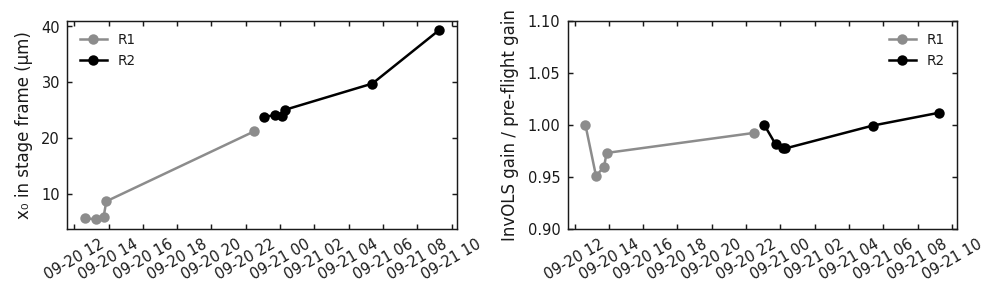

In [3]:
fig, axs = fp.figure("double", aspect=0.3, ncols=2)
for tag, a in an.items():
    c = "0.55" if tag == "R1" else "k"
    axs[0].plot(a.t, a.x0, "o-", color=c, ms=4, label=tag)
    axs[1].plot(a.t, a.gain_rel, "o-", color=c, ms=4, label=tag)
axs[0].set_ylabel("x₀ in stage frame (µm)")
axs[1].set_ylabel("InvOLS gain / pre-flight gain"); axs[1].set_ylim(0.9, 1.1)
for ax in axs:
    ax.tick_params(axis="x", rotation=30); ax.legend()
fig.tight_layout(); fp.save(fig, "05_frame_drift")

**Reading.**
- The detector gain stays within ±2–5 % all night.
- The clamp position drifts in stage coordinates. R1: 5.7 → 8.7 µm in the first 1.5 h, then
  21.2 µm at the close-out (after the load ladder). R2 starts at 23.8 µm, continuous with R1's
  close-out. It drifts ~0.9 µm/h overnight (25.0 → 29.8 µm) and reaches 39.3 µm after the
  morning load extension.
- So most of what looked like InvOLS "ageing" (SI-a) is the laser moving along the lever, by
  about 1 µm/h plus jumps during load excursions. The per-stop InvOLS is still the right number
  for pm/V conversion. Positions, however, have to be put into the lever frame.
- The R2 "free end" at stage 232 µm is really ~208 µm from the clamp (~18 µm inside the tip).
  This is why the R2 free end looked much less node-like than in R1.

## Dense-map nodes in the lever frame

In [4]:
states, node_rows = {}, []
for tag, (camp, d0, dense) in CAMP.items():
    s = F.load(f"scmpitB_{tag.lower()}_dense")
    t_at_x = tl[tag][tl[tag].stage == dense].groupby("x_um").t.median()
    fr, nodes = {}, {}
    for b in ("CR1", "CR2", "CR3"):
        pk = spectra.peaks_along_x(s.freq_Hz, s.Z[0], s.probe.bands_Hz[b])
        fr[b] = float(np.median(pk["f_Hz"]))
        if b == "CR1":
            Q1 = float(np.nanmedian(pk["Q"])); continue
        lever = []
        for n in spectra.nodes_from_profile(s.x_um, pk["amp"]):
            tn = t_at_x.iloc[int(np.argmin(np.abs(t_at_x.index.values - n)))]
            x0n = float(calib.x0_at(an[tag], tn)[0])
            lever.append(n - x0n)
            node_rows.append(dict(run=tag, mode=b, stage_um=n, old_frame_um=n - 6.1,
                                  x0_at_time=x0n, lever_frame_um=n - x0n, time=tn))
        nodes[b] = lever
    sv = tl[tag][(tl[tag].stage == "10_bias_survey") & tl[tag].ratio.between(0.7, 1.6)].groupby("x_um").invols.median()
    x0s = float(an[tag].set_index("stage").loc["10_bias_survey", "x0"])
    xs = sv.index.values - x0s; keep = xs < L_UM - 10
    states[tag] = eb_fit.ContactState(f"{tag} dense-map state", np.array([fr["CR1"], fr["CR2"], fr["CR3"]]),
                                      Q1, xs[keep], sv.values[keep], nodes, L_um=L_UM)
nodes_tbl = pd.DataFrame(node_rows)
nodes_tbl.round(1)

/tmp/ipykernel_365/770656091.py:25: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  nodes_tbl.round(1)


,run,mode,stage_um,old_frame_um,x0_at_time,lever_frame_um,time
0,R1,CR2,139.0,132.9,12.3,126.7,2026-09-20 16:22:18
1,R1,CR3,103.0,96.9,13.4,89.6,2026-09-20 17:05:36
2,R1,CR3,174.0,167.9,11.3,162.7,2026-09-20 15:40:30
3,R2,CR2,153.0,146.9,28.1,124.9,2026-09-21 03:34:22
4,R2,CR3,117.0,110.9,28.7,88.3,2026-09-21 04:17:22
5,R2,CR3,185.0,178.9,27.5,157.5,2026-09-21 02:56:28


In [5]:
piv = nodes_tbl.assign(k=nodes_tbl.groupby(["run", "mode"]).cumcount()).pivot_table(
    index=["mode", "k"], columns="run", values=["old_frame_um", "lever_frame_um"])
piv[("shift", "old frame")] = piv[("old_frame_um", "R2")] - piv[("old_frame_um", "R1")]
piv[("shift", "lever frame")] = piv[("lever_frame_um", "R2")] - piv[("lever_frame_um", "R1")]
piv.round(1)

lever_frame_um        old_frame_um            shift            
run                R1     R2           R1     R2 old frame lever frame
mode k                                                                
CR2  0          126.7  124.9        132.9  146.9      14.0        -1.8
CR3  0           89.6   88.3         96.9  110.9      14.0        -1.4
     1          162.7  157.5        167.9  178.9      11.0        -5.2

In the fixed frame the nodes appear to move +11 to +14 µm. In the lever frame they move −1 to −6 µm,
toward the clamp. For R1 the dense map was taken between the last early anchor (13:52) and the
close-out (22:29), with the load ladder in between. The linear x₀ interpolation used for R1
therefore carries about ±1.5 µm of extra uncertainty.

## Blind Euler–Bernoulli fit of each contact state

The fit sees CR1–CR3, Q₁ and the static InvOLS shape (lever frame, L = 226.5 µm); nodes are
withheld (`use_nodes=False`). A second fit adds the nodes to check consistency. Expect ~3–5 min per
fit on the laptop.

In [6]:
fits = {}
for tag, st in states.items():
    for use_nodes in (False, True):
        r = eb_fit.fit(st, use_nodes=use_nodes)
        s = eb_fit.summarize(r.x, st); s["use_nodes"] = use_nodes; s["p"] = r.x.tolist()
        fits[(tag, use_nodes)] = s
rows = []
for (tag, un), s in fits.items():
    rows.append(dict(run=tag, fit="with nodes" if un else "blind", k_star_over_k=s["k_ratio"],
                     kcone_over_k=s["kcone_ratio"], setback_um=s["setback_um"], zeta=s["zeta"],
                     tip_height_um=s["tip_height_um"], cr_err_pct=s["cr_err_pct"], Q_model=s["Q_model"],
                     static_rms_pct=s["static_rms_pct"]))
pd.DataFrame(rows).round(3)

,run,fit,k_star_over_k,kcone_over_k,setback_um,zeta,tip_height_um,cr_err_pct,Q_model,static_rms_pct
0,R1,blind,479.509,1.002,2.172,0.003,6.070,"[-0.82, 0.23, -0.02]",235.225,2.289
1,R1,with nodes,482.321,1.100,2.699,0.003,6.558,"[-0.55, 0.67, 0.21]",236.333,2.326
2,R2,blind,744.071,1.523,5.286,0.003,6.596,"[-1.39, 0.99, -0.23]",246.172,2.082
3,R2,with nodes,766.656,1.639,5.086,0.003,6.643,"[-1.39, 0.9, -0.02]",245.791,2.083


In [7]:
cmp = []
for tag in states:
    blind = fits[(tag, False)]["nodes_model_um"]
    for mode in ("CR2", "CR3"):
        for i, meas in enumerate(states[tag].nodes_um.get(mode, [])):
            pred = min(blind[mode], key=lambda v: abs(v - meas)) if blind[mode] else np.nan
            cmp.append(dict(run=tag, mode=mode, measured_lever_um=meas, blind_EB_um=pred, diff_um=pred - meas))
cmp = pd.DataFrame(cmp); cmp.round(2)

,run,mode,measured_lever_um,blind_EB_um,diff_um
0,R1,CR2,126.67,127.28,0.61
1,R1,CR3,89.62,92.20,2.58
2,R1,CR3,162.68,164.36,1.68
3,R2,CR2,124.91,124.78,-0.14
4,R2,CR3,88.25,88.70,0.44
5,R2,CR3,157.49,158.85,1.36


[PosixPath('/home/claude/work/paper_analysis/figures/05_nodes_blind_prediction.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/05_nodes_blind_prediction.pdf')]

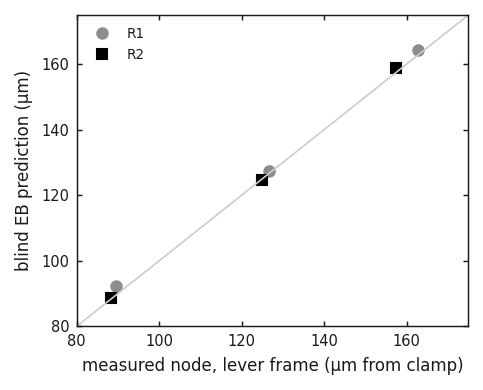

In [8]:
fig, ax = fp.figure("single", aspect=0.8)
for tag, mk in (("R1", "o"), ("R2", "s")):
    d = cmp[cmp.run == tag]
    ax.plot(d.measured_lever_um, d.blind_EB_um, mk, color="k" if tag == "R2" else "0.55", ms=5, label=tag)
lim = [80, 175]; ax.plot(lim, lim, color="0.8", lw=0.8)
old = nodes_tbl.groupby(["run", "mode", "stage_um"]).first().reset_index()
ax.set_xlabel("measured node, lever frame (µm from clamp)"); ax.set_ylabel("blind EB prediction (µm)")
ax.legend(); ax.set_xlim(lim); ax.set_ylim(lim)
fp.save(fig, "05_nodes_blind_prediction")

**Result.**
- Blind fits that never saw a node place all six interior nodes within ~0–3 µm of the
  drift-corrected measurements. Adding the nodes to the fit barely changes the parameters.
- Between the two dense maps the contact became stiffer (k*/k_lever ~480 → ~750) and the
  effective tip setback grew by ~3 µm (≈2.5 → 5 µm). Frequencies rose 3–8 % and the nodes moved a
  few µm toward the clamp. This is consistent with a blunter tip after the R1 load ladder.

**What changes in the manuscript.**
- "Every node moved 11–14 µm toward the free end" is a laser-frame artefact. Replace it with the
  lever-frame shift and the blind-fit prediction.
- R2 positions quoted "from the clamp" with the 6.1 µm offset are ~18 µm too large; use x − x₀(t).
- "The free end became less node-like / enhancement went stale" at stage 232 µm is mostly the laser
  drifting ~15 µm inward, not a change in the node.
- Positive message for the paper: a force curve at each stop already provides an *in-situ* position
  ruler (same idea as draft Sec. S1), so autonomous acquisition can correct laser drift as it goes.

In [9]:
results.save("fig5_contact_state",
             dict(anchors={t: a.assign(t=a.t.astype(str)).to_dict("records") for t, a in an.items()},
                  nodes=nodes_tbl.assign(time=nodes_tbl.time.astype(str)).to_dict("records"),
                  fits={f"{k[0]}|{'nodes' if k[1] else 'blind'}": v for k, v in fits.items()},
                  node_prediction=cmp.to_dict("records")),
             table=cmp)

PosixPath('/home/claude/work/paper_analysis/results/fig5_contact_state.json')